# 🚗 License Plate Recognition — Adaptive Image Processing Pipeline

| Function | Member | Stage | Adaptive Behaviour |
|---|---|---|---|
| `m1_edge_detection` | M1 | Grayscale + CLAHE + Bilateral + Canny | Auto-tunes Canny thresholds via Otsu; CLAHE for dark/bright images |
| `m2_plate_candidate` | M2 | Morph Closing + Contour Filtering | Multi-pass search with relaxing constraints; scoring by position+area+aspect |
| `m3_perspective_binarize` | M3 | Perspective Correction + Binarization | Picks Otsu vs Adaptive based on local contrast; dynamic output size |


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets
import os, warnings
warnings.filterwarnings('ignore')
print('Libraries loaded ✓')

Libraries loaded ✓


## 1: Adaptive Grayscale + Bilateral Filter + Edge Detection

In [2]:
def m1_edge_detection(image_path, visualize=True):
    original = cv2.imread(image_path)
    if original is None:
        raise FileNotFoundError(f"Cannot open image: {image_path}")

    h, w = original.shape[:2]
    gray_raw = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

    mean_intensity = np.mean(gray_raw)
    contrast = np.std(gray_raw)
    texture = cv2.Laplacian(gray_raw, cv2.CV_64F).var()

    # CLAHE: more conservative scaling (less noise amplification)
    clip = np.clip(2.0 + (50.0 / (contrast + 1e-5)), 2.0, 5.0)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8, 8))
    gray = clahe.apply(gray_raw)

    # Bilateral: driven more by texture than raw std
    base = max(5, min(15, int(min(h, w) / 60) * 2 + 1))
    sigma = np.clip(0.3 * contrast + 0.2 * texture**0.5, 10, 60)

    filtered = cv2.bilateralFilter(gray, base, sigma, sigma)

    # Canny: still Otsu-based but stabilized
    blurred = cv2.GaussianBlur(filtered, (5, 5), 0)
    otsu_val, _ = cv2.threshold(
        blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    edge_density_bias = np.clip(texture / 1000.0, 0.8, 1.3)

    canny_low = int(np.clip(0.4 * otsu_val * edge_density_bias, 10, 120))
    canny_high = int(np.clip(1.2 * otsu_val * edge_density_bias, 80, 250))

    edges = cv2.Canny(filtered, canny_low, canny_high)

    meta = dict(
        clip=round(clip, 2),
        bilateral_d=base,
        sigma=round(float(sigma), 2),
        canny=[canny_low, canny_high],
        mean=int(mean_intensity),
        contrast=round(contrast, 1),
        texture=round(texture, 1)
    )

    if visualize:
        fig, axes = plt.subplots(1, 4, figsize=(20, 4))
        axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
        axes[0].set_title(f"Original {w}x{h}")
        axes[1].imshow(gray_raw, cmap="gray")
        axes[1].set_title("Grayscale")
        axes[2].imshow(gray, cmap="gray")
        axes[2].set_title(f"CLAHE clip={clip:.2f}")
        axes[3].imshow(edges, cmap="gray")
        axes[3].set_title(f"Canny {canny_low}-{canny_high}")

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

        print(meta)

    return original, gray, edges, meta

## 2: Adaptive Morph Closing + Contour Filtering

In [3]:
def m2_plate_candidate(original, edges, visualize=True):
    """
    M2: License plate candidate detection.
    Uses the proven PyImageSearch ANPR approach:
      1. BLACKHAT morphology to reveal dark text on light plates
      2. TOPHAT morphology to reveal light text on dark plates
      3. Scharr gradient in x-direction to find character regions
      4. Otsu threshold + morphological cleanup
      5. Contour ranking with adaptive aspect/size filters
    Works on both light-background and dark-background plates.
    Returns: plate_crop (BGR), best_contour, best_rect (x,y,w,h), meta
    """
    img_h, img_w = edges.shape
    img_area     = img_h * img_w

    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)

    # ── Step 1: Adaptive rect kernel (scaled to image size) ─────────
    # Standard plate ratio ~13:5 scaled to image
    kw = max(13, int(img_w * 0.025)) | 1
    kh = max(5,  int(img_h * 0.015)) | 1
    rect_kern = cv2.getStructuringElement(cv2.MORPH_RECT, (kw, kh))
    sq_kern   = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

    # ── Step 2: BLACKHAT — dark text on light plate ──────────────────
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, rect_kern)

    # ── Step 3: TOPHAT — light text on dark plate ────────────────────
    tophat   = cv2.morphologyEx(gray, cv2.MORPH_TOPHAT,   rect_kern)

    # ── Step 4: Scharr gradient (x-direction) on each ───────────────
    def scharr_thresh(img):
        grad = cv2.Scharr(img, cv2.CV_32F, 1, 0)
        grad = np.absolute(grad)
        mn, mx = grad.min(), grad.max()
        if mx - mn < 1e-5:
            return np.zeros_like(img, dtype=np.uint8)
        grad = (255 * (grad - mn) / (mx - mn)).astype(np.uint8)
        blurred = cv2.GaussianBlur(grad, (5, 5), 0)
        _, thresh = cv2.threshold(
            blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
        # close gaps between characters
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, rect_kern)
        # denoise
        thresh = cv2.erode(thresh,  sq_kern, iterations=2)
        thresh = cv2.dilate(thresh, sq_kern, iterations=2)
        return thresh

    thresh_black = scharr_thresh(blackhat)
    thresh_top   = scharr_thresh(tophat)

    # ── Step 5: Also try traditional edge-based morph ────────────────
    morph_edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, rect_kern)

    sources = [
        ("blackhat", thresh_black),
        ("tophat",   thresh_top),
        ("edges",    morph_edges),
    ]

    # ── Step 6: Contour scoring ──────────────────────────────────────
    def score_contour(cnt, x, y, w, h):
        area     = w * h
        ar_frac  = area / float(img_area)
        aspect   = w / float(h + 1e-5)

        # Hard gates — must pass ALL
        if ar_frac < 0.003 or ar_frac > 0.40:   return -1  # too small/large
        if aspect   < 1.0  or aspect   > 9.0:    return -1  # wrong shape
        if w < img_w * 0.04:                      return -1  # too narrow
        if h > img_h * 0.25:                      return -1  # too tall
        # reject near-full-image boxes
        if w > img_w * 0.90 and h > img_h * 0.90: return -1

        # Soft scoring
        asp_score  = max(0.0, 1.0 - abs(aspect - 4.0) / 5.0)
        fill       = cv2.contourArea(cnt) / (area + 1e-5)
        edge_den   = float(np.mean(edges[y:y+h, x:x+w])) / 255.0
        y_c        = (y + h / 2.0) / img_h
        pos        = 1.0 + 0.4 * (0.25 < y_c < 0.95)
        size_score = 1.0 - ar_frac   # prefer smaller (not full image)

        return (0.30 * asp_score +
                0.25 * fill       +
                0.25 * edge_den   +
                0.20 * size_score ) * pos

    best_score   = -1
    best_contour = None
    best_rect    = None
    best_source  = None

    for sname, thresh in sources:
        cnts, _ = cv2.findContours(
            thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        # sort by area descending, check top 10 only (efficiency)
        cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:10]
        for cnt in cnts:
            x, y, w, h = cv2.boundingRect(cnt)
            s = score_contour(cnt, x, y, w, h)
            if s > best_score:
                best_score, best_contour, best_rect, best_source = s, cnt, (x,y,w,h), sname

    # ── Step 7: Relaxed fallback (drop size/aspect gates) ───────────
    if best_contour is None:
        print("[M2] Strict pass found nothing — relaxed fallback")
        for sname, thresh in sources:
            cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cnts = sorted(cnts, key=cv2.contourArea, reverse=True)[:5]
            for cnt in cnts:
                x, y, w, h = cv2.boundingRect(cnt)
                if w * h < img_area * 0.001:        continue
                if w > img_w * 0.92 and h > img_h * 0.92: continue
                s = float(np.mean(edges[y:y+h, x:x+w])) / 255.0
                if s > best_score:
                    best_score, best_contour, best_rect, best_source = s, cnt, (x,y,w,h), sname+"_relaxed"

    # ── Last resort ──────────────────────────────────────────────────
    if best_contour is None:
        print("[M2] No candidate found — full image fallback")
        best_rect    = (0, 0, img_w, img_h)
        best_contour = np.array([[[0,0]],[[img_w,0]],[[img_w,img_h]],[[0,img_h]]])
        best_source  = "fallback"
        best_score   = 0.0

    # ── Padding ──────────────────────────────────────────────────────
    x, y, w, h = best_rect
    pad_x = max(4, int(w * 0.03))
    pad_y = max(4, int(h * 0.06))
    x1 = max(0,     x - pad_x)
    y1 = max(0,     y - pad_y)
    x2 = min(img_w, x + w + pad_x)
    y2 = min(img_h, y + h + pad_y)
    best_rect  = (x1, y1, x2-x1, y2-y1)
    plate_crop = original[y1:y2, x1:x2]

    meta = {
        "score":  round(best_score, 4),
        "source": best_source,
        "kernel": f"{kw}x{kh}",
        "rect":   best_rect,
    }

    if visualize:
        debug = original.copy()
        rx, ry, rw, rh = best_rect
        cv2.rectangle(debug, (rx, ry), (rx+rw, ry+rh), (0, 220, 60), 3)
        cv2.putText(debug, f"{best_source} | score={best_score:.3f}",
                    (rx, max(ry-10, 20)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,220,60), 2)

        fig, axes = plt.subplots(1, 4, figsize=(22, 4))
        axes[0].imshow(blackhat, cmap="gray");                          axes[0].set_title("Blackhat")
        axes[1].imshow(tophat,   cmap="gray");                          axes[1].set_title("Tophat")
        axes[2].imshow(cv2.cvtColor(debug, cv2.COLOR_BGR2RGB));         axes[2].set_title(f"Detection [{best_source}]")
        axes[3].imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB));    axes[3].set_title("Plate Crop")
        for ax in axes: ax.axis("off")
        plt.tight_layout(); plt.show()
        print("[M2]", meta)

    return plate_crop, best_contour, best_rect, meta


## 3: Adaptive Perspective Correction + Binarization

In [4]:
def m3_perspective_binarize(original, best_rect, edges=None, visualize=True):
    """
    M3: Perspective correction + adaptive binarization (robust version)

    Key upgrades:
      - Multi-candidate warping (quad + rotated rect + fallback)
      - Warp quality scoring instead of single-path trust
      - Realistic aspect ratio constraints (not strict inheritance from M2)
      - Data-driven binarization selection (Otsu vs Adaptive)
      - Post-warp validation signal

    Returns:
      binary_plate, best_warped, meta
    """

    gray = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    x, y, w, h = best_rect

    crop_gray = gray[y:y+h, x:x+w]

    # ----------------------------
    # Step 1: edge + contour search
    # ----------------------------
    blurred = cv2.GaussianBlur(crop_gray, (3, 3), 0)
    _, crop_edges = cv2.threshold(
        blurred, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    contours, _ = cv2.findContours(
        crop_edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # ----------------------------
    # Step 2: candidate geometry extraction
    # ----------------------------
    candidates = []

    # A) Best contour quad attempt
    if contours:
        biggest = max(contours, key=cv2.contourArea)
        peri = cv2.arcLength(biggest, True)

        for eps in [0.02, 0.03, 0.05, 0.08]:
            approx = cv2.approxPolyDP(biggest, eps * peri, True)
            if len(approx) == 4:
                quad = approx.reshape(4, 2).astype(np.float32)
                quad[:, 0] += x
                quad[:, 1] += y
                candidates.append(("quad", quad))
                break

    # B) Rotated rectangle fallback
    rect = cv2.minAreaRect(
        max(contours, key=cv2.contourArea)
    ) if contours else None

    if rect is not None:
        box = cv2.boxPoints(rect).astype(np.float32)
        box[:, 0] += x
        box[:, 1] += y
        candidates.append(("rotated_rect", box))

    # C) Hard fallback bounding box
    candidates.append((
        "bbox",
        np.array([[x, y], [x+w, y], [x+w, y+h], [x, y+h]], dtype=np.float32)
    ))

    # ----------------------------
    # Step 3: geometry ordering
    # ----------------------------
    def order_points(pts):
        rect = np.zeros((4, 2), dtype=np.float32)
        s = pts.sum(axis=1)
        d = np.diff(pts, axis=1).ravel()
        rect[0] = pts[np.argmin(s)]
        rect[2] = pts[np.argmax(s)]
        rect[1] = pts[np.argmin(d)]
        rect[3] = pts[np.argmax(d)]
        return rect

    # ----------------------------
    # Step 4: warp scoring function
    # ----------------------------
    def warp_score(warp):
        if warp is None:
            return -1

        # warp is already grayscale (warped from gray via warpPerspective)
        g = warp if len(warp.shape) == 2 else cv2.cvtColor(warp, cv2.COLOR_BGR2GRAY)

        # character structure signal
        edge_var = cv2.Laplacian(g, cv2.CV_64F).var()

        # binarization stability proxy
        std = np.std(g)

        # foreground balance (not too empty, not too full)
        _, bin_tmp = cv2.threshold(
            g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
        fg_ratio = np.mean(bin_tmp == 255)

        balance = 1.0 - abs(fg_ratio - 0.5)

        return (
            0.5 * min(edge_var / 500.0, 1.0) +
            0.3 * balance +
            0.2 * min(std / 80.0, 1.0)
        )

    # ----------------------------
    # Step 5: warp + evaluation
    # ----------------------------
    best_warp = None
    best_binary = None
    best_meta = None
    best_score = -1

    for mode, pts in candidates:
        src = order_points(pts)

        # adaptive output size (clamped realism)
        h_out = 80
        aspect = w / float(h + 1e-5)
        aspect = np.clip(aspect, 2.0, 6.5)
        w_out = int(np.clip(h_out * aspect, 160, 480))

        dst = np.array(
            [[0, 0], [w_out-1, 0], [w_out-1, h_out-1], [0, h_out-1]],
            dtype=np.float32
        )

        M = cv2.getPerspectiveTransform(src, dst)
        warped = cv2.warpPerspective(gray, M, (w_out, h_out))

        score = warp_score(warped)

        if score > best_score:
            best_score = score
            best_warp = warped
            best_meta = mode

    # ----------------------------
    # Step 6: adaptive binarization
    # ----------------------------
    local_std = float(np.std(best_warp))

    otsu_bin = cv2.threshold(
        best_warp, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]

    block = max(11, int(best_warp.shape[1] / 15) | 1)
    adaptive_bin = cv2.adaptiveThreshold(
        best_warp, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block, 4
    )

    def bin_quality(b):
        return np.mean(b == 255) * np.std(b)

    binary = otsu_bin if bin_quality(otsu_bin) > bin_quality(adaptive_bin) else adaptive_bin

    # fix polarity
    if np.mean(binary) < 127:
        binary = cv2.bitwise_not(binary)

    binary = cv2.medianBlur(binary, 3)

    meta = {
        "warp_mode": best_meta,
        "warp_score": round(best_score, 4),
        "local_std": round(local_std, 1),
        "out_size": best_warp.shape[::-1],
        "binarization": "otsu_vs_adaptive"
    }

    # ----------------------------
    # Step 7: visualization
    # ----------------------------
    if visualize:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        axes[0].imshow(gray[y:y+h, x:x+w], cmap="gray")
        axes[0].set_title("Input Crop (M2)")

        axes[1].imshow(best_warp, cmap="gray")
        axes[1].set_title(f"Warped [{best_meta}] score={best_score:.3f}")

        axes[2].imshow(binary, cmap="gray")
        axes[2].set_title(f"Binary std={local_std:.0f}")

        for ax in axes:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

        print("[M3]", meta)

    return binary, best_warp, meta

##  Characters Segmentation

In [5]:
def m4_segment_characters(binary_image, visualize=True):
    """
    Segment characters from binarized license plate.
    
    Args:
        binary_image: Binary image from M3 (black chars, white background, or vice versa)
        visualize: Show segmentation steps and results
    
    Returns:
        character_images: List of segmented character images (resized to ~20×30)
        char_image_paths: List of paths where character images were saved
        meta: Dictionary with segmentation metadata
    """
    


    white_pixels = np.sum(binary_image == 255)
    black_pixels = np.sum(binary_image == 0)
    if white_pixels > black_pixels:
        binary_image = cv2.bitwise_not(binary_image)

        
    # Ensure binary image is uint8 format
    if binary_image.dtype != np.uint8:
        binary_image = (binary_image * 255).astype(np.uint8)
    
    # If binary image has 3 channels, convert to grayscale
    if len(binary_image.shape) == 3:
        binary_image = cv2.cvtColor(binary_image, cv2.COLOR_BGR2GRAY)
    
    h, w = binary_image.shape
    
    # Ensure text is black on white background (if not, invert)
    white_pixels = np.sum(binary_image == 255)
    black_pixels = np.sum(binary_image == 0)
    if black_pixels > white_pixels:
        binary_image = cv2.bitwise_not(binary_image)
    
    # ============================================
    # Step 1: Remove small noisy components (morph open)
    # ============================================
    
    # Adaptive kernel size based on image dimensions
    kernel_size = max(2, int(min(h, w) / 50))
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    
    # Morphological opening to remove noise
    cleaned = cv2.morphologyEx(binary_image, cv2.MORPH_OPEN, kernel)


    erosion_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    cleaned = cv2.erode(cleaned, erosion_kernel, iterations=1)
    
    # Additional noise removal by contour area filtering
    contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    min_char_area = (h * w) * 0.003  # Minimum 0.3% of plate area
    
    # Create mask with only sufficiently large components
    mask = np.zeros_like(cleaned)
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area > min_char_area:
            cv2.drawContours(mask, [cnt], -1, 255, -1)
    
    cleaned = cv2.bitwise_and(cleaned, mask)
    
    # ============================================
    # Step 2: Isolate characters using Connected Components (CCL)
    # ============================================
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        cv2.bitwise_not(cleaned), 
        connectivity=8
    )    
    char_regions = []  # Store (character_image, x_position, y_position)
    
    for i in range(1, num_labels):  # Skip background (label 0)
        x, y, cw, ch, area = stats[i]
        
        # Filter criteria for valid characters
        aspect_ratio = cw / max(ch, 1)
        
        # Character should be:
        # - Height between 5% and 85% of plate height
        # - Width between 2% and 60% of plate width
        # - Aspect ratio between 0.2 and 1.5 (typical for letters/digits)
        # - Area not too small
        if (ch > h * 0.05 and ch < h * 0.85 and
            cw > w * 0.02 and cw < w * 0.60 and
            aspect_ratio > 0.2 and aspect_ratio < 1.5 and
            area > min_char_area):
            
            # Add small padding around character
            pad_x = max(1, int(cw * 0.1))
            pad_y = max(1, int(ch * 0.1))
            
            x1 = max(0, x - pad_x)
            y1 = max(0, y - pad_y)
            x2 = min(w, x + cw + pad_x)
            y2 = min(h, y + ch + pad_y)
            
            char_region = cleaned[y1:y2, x1:x2]
            char_regions.append((char_region, x1, y1))
    
    # ============================================
    # Fallback: Vertical projection if CCL didn't find enough characters
    # ============================================
    
    if len(char_regions) < 3:
        print("[M4] CCL found few characters, falling back to vertical projection...")
        char_regions = vertical_projection_segmentation(cleaned, h, w, min_char_area)
    
    # ============================================
    # Step 3: Sort left-to-right by x-coordinate
    # ============================================
    
    char_regions.sort(key=lambda x: x[1])  # Sort by x position
    
    # ============================================
    # Step 4: Save each character as separate image (20×30 approx)
    # ============================================
    
    # Create directory for character images
    chars_dir = "segmented_chars"
    os.makedirs(chars_dir, exist_ok=True)
    
    character_images = []
    char_image_paths = []
    
    target_h, target_w = 30, 20  # Target dimensions (height × width)
    
    for idx, (char_img, x_pos, y_pos) in enumerate(char_regions):
        # Get current dimensions
        ch_h, ch_w = char_img.shape
        
        # Calculate scaling to fit within target while preserving aspect ratio
        scale = min(target_w / ch_w, target_h / ch_h)
        new_w = int(ch_w * scale)
        new_h = int(ch_h * scale)
        
        # Resize
        resized = cv2.resize(char_img, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
        
        # Create white canvas and center the character
        padded = np.ones((target_h, target_w), dtype=np.uint8) * 255
        x_offset = (target_w - new_w) // 2
        y_offset = (target_h - new_h) // 2
        padded[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized
        
        # Save character image
        save_path = os.path.join(chars_dir, f"char_{idx:02d}.png")
        cv2.imwrite(save_path, padded)
        
        character_images.append(padded)
        char_image_paths.append(save_path)
    
    # ============================================
    # Metadata
    # ============================================
    
    meta = {
        "num_characters": len(character_images),
        "method": "CCL" if len(char_regions) >= 3 else "Vertical Projection",
        "target_size": f"{target_h}×{target_w}",
        "output_directory": chars_dir,
        "image_dimensions": f"{w}×{h}"
    }
    
    # ============================================
    # Visualization
    # ============================================
    
    if visualize:
        # 1. Calculate how many columns we need (Characters + 2 for the status images)
        num_chars = len(character_images)
        num_cols = num_chars + 2
        
        # 2. Adjust figsize width dynamically so it doesn't get squashed
        fig, axes = plt.subplots(2, num_cols, figsize=(num_cols * 2.5, 7))
        
        # If there's only one column (rare), axes won't be a 2D array, fix that:
        if num_cols == 1: axes = np.expand_dims(axes, axis=1)

        # Original binary
        axes[0, 0].imshow(binary_image, cmap='gray')
        axes[0, 0].set_title("1. Original Binary")
        axes[0, 0].axis('off')
        
        # After morph open (cleaned)
        axes[0, 1].imshow(cleaned, cmap='gray')
        axes[0, 1].set_title("2. After Morph")
        axes[0, 1].axis('off')
        
        for i, char_img in enumerate(character_images):
            col = i + 2
            axes[0, col].imshow(char_img, cmap='gray')
            axes[0, col].set_title(f"Char {i}\n{char_img.shape[1]}x{char_img.shape[0]}")
            axes[0, col].axis('off')
        
        # Bounding boxes (bottom row)
        debug_img = cv2.cvtColor(cleaned, cv2.COLOR_GRAY2BGR)
        for i, (_, x_pos, y_pos) in enumerate(char_regions):
            char_img = char_regions[i][0]
            ch_h, ch_w = char_img.shape
            cv2.rectangle(debug_img, (x_pos, y_pos), (x_pos + ch_w, y_pos + ch_h), (0, 255, 0), 2)
            cv2.putText(debug_img, str(i), (x_pos, y_pos - 5), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        
        axes[1, 0].imshow(debug_img)
        axes[1, 0].set_title(f"Detected: {len(char_regions)}")
        axes[1, 0].axis('off')
        
        # Hide the extra empty subplots in the second row
        for j in range(1, num_cols):
            axes[1, j].axis('off')

        plt.tight_layout()
        plt.show()
        
        print("\n" + "="*50)
        print("[M4] Segmentation Complete")
        print("="*50)
        print(f"  → Characters found: {len(character_images)}")
        print(f"  → Method used: {meta['method']}")
        print(f"  → Saved to: {chars_dir}/")
        for i, path in enumerate(char_image_paths):
            print(f"      char_{i:02d}.png ({character_images[i].shape[1]}×{character_images[i].shape[0]})")
        print("="*50)
    
    return character_images, char_image_paths, meta

def vertical_projection_segmentation(cleaned, h, w, min_char_area):
    """
    Fallback method: Vertical projection to find character gaps.
    Used when CCL doesn't find enough characters.
    """
    # Vertical projection histogram (sum of white pixels per column)
    vertical_projection = np.sum(cleaned == 0, axis=0)    
    # Find gaps (columns with very few white pixels)
    threshold = np.max(vertical_projection) * 0.2
    
    char_regions = []
    in_character = False
    start_x = 0
    
    for x in range(w):
        if vertical_projection[x] < threshold and in_character:
            # End of character
            if x - start_x > w * 0.01:  # Minimum width
                char_region = cleaned[:, start_x:x]
                char_regions.append((char_region, start_x, 0))
            in_character = False
        elif vertical_projection[x] >= threshold and not in_character:
            # Start of character
            start_x = x
            in_character = True
    
    # Last character
    if in_character and w - start_x > w * 0.01:
        char_region = cleaned[:, start_x:w]
        char_regions.append((char_region, start_x, 0))
    
    return char_regions

In [6]:
def review_segmented_characters(plate_crop, binary_image, character_images, char_positions):
    """
    Display segmented characters alongside the original plate crop for verification.
    This helps you check if M4 correctly isolated each character.
    """
    fig, axes = plt.subplots(1, len(character_images) + 2, 
                             figsize=((len(character_images) + 2) * 2, 4))
    
    # Original plate crop
    axes[0].imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original Plate")
    axes[0].axis('off')
    
    # Binary image used for segmentation
    axes[1].imshow(binary_image, cmap='gray')
    axes[1].set_title("Binary (M3 output)")
    axes[1].axis('off')
    
    # Each segmented character
    for i, (char_img, (x, y)) in enumerate(zip(character_images, char_positions)):
        axes[i + 2].imshow(char_img, cmap='gray')
        axes[i + 2].set_title(f"Char {i}\npos=({x},{y})")
        axes[i + 2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print the assembled text from OCR
    print(f"\nAssembled from segmentation order: {''.join([str(i) for i in range(len(character_images))])}")

In [7]:

import pytesseract

# Set the path to tesseract (adjust path if you installed elsewhere)
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

try:
    version = pytesseract.get_tesseract_version()
    print(f"Tesseract version: {version}")
except Exception as e:
    print(f"Tesseract not found. Please install from: https://github.com/UB-Mannheim/tesseract/wiki")
    print(f"Error: {e}")

Tesseract version: 5.5.0.20241111


In [8]:
import pytesseract
import sqlite3, re, csv
from datetime import datetime
import subprocess, sys, shutil, os

def m5_ocr(character_images, char_paths=None, visualize=True):
    """
    OCR each segmented character and assemble the full plate string.

    Args:
        character_images: list of NumPy arrays from M4 (already 20×30, black-on-white)
        char_paths:       optional list of file paths matching character_images
        visualize:        show each character with its predicted label

    Returns:
        plate_text:    assembled plate string (e.g. 'ABC1234')
        per_char:      list of (predicted_char, confidence) tuples
        meta:          dictionary with OCR metadata
    """

    sep = "─" * 55

    def preprocess_for_ocr(char_img, scale=4, pad=10):
        """Tesseract works better when the char is bigger and surrounded by white."""
        if len(char_img.shape) == 3:
            char_img = cv2.cvtColor(char_img, cv2.COLOR_BGR2GRAY)

        # ensure black text on white background
        if np.mean(char_img) < 127:
            char_img = cv2.bitwise_not(char_img)

        # upscale (Tesseract dislikes tiny inputs)
        h, w = char_img.shape
        char_img = cv2.resize(char_img, (w * scale, h * scale),
                              interpolation=cv2.INTER_CUBIC)

        # re-threshold after resize so edges stay crisp
        _, char_img = cv2.threshold(char_img, 127, 255,
                                    cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # white border
        char_img = cv2.copyMakeBorder(char_img, pad, pad, pad, pad,
                                      cv2.BORDER_CONSTANT, value=255)
        return char_img

    # Tesseract config — single character, plate alphabet only
    OCR_CONFIG = (
        '--oem 3 --psm 10 '
        '-c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789'
    )

    per_char = []
    processed_imgs = []

    if not character_images:
        print("[M5] No characters received from M4 — nothing to OCR")
        return "", [], {"num_chars": 0, "engine": "tesseract"}

    for idx, ch in enumerate(character_images):
        proc = preprocess_for_ocr(ch)
        processed_imgs.append(proc)

        # image_to_data gives us per-character confidence too
        data = pytesseract.image_to_data(
            proc, config=OCR_CONFIG, output_type=pytesseract.Output.DICT
        )

        # pick the most confident non-empty token
        best_char, best_conf = '?', -1
        for txt, cf in zip(data['text'], data['conf']):
            txt = re.sub(r'[^A-Z0-9]', '', txt.upper())
            try:
                cf = float(cf)
            except (ValueError, TypeError):
                cf = -1
            if txt and cf > best_conf:
                best_char, best_conf = txt[0], cf

        # second-chance: try psm 8 (single word) if psm 10 failed
        if best_char == '?':
            txt2 = pytesseract.image_to_string(
                proc, config=OCR_CONFIG.replace('--psm 10', '--psm 8')
            )
            txt2 = re.sub(r'[^A-Z0-9]', '', txt2.upper())
            if txt2:
                best_char, best_conf = txt2[0], 50.0  # rough confidence

        per_char.append((best_char, best_conf))

    plate_text = ''.join(c for c, _ in per_char)
    valid_confs = [c for _, c in per_char if c >= 0]
    avg_conf = float(np.mean(valid_confs)) if valid_confs else 0.0
    # Clamp NaN to 0.0 (happens when all OCR attempts fail)
    if np.isnan(avg_conf):
        avg_conf = 0.0

    meta = {
        "num_chars": len(character_images),
        "plate_text": plate_text,
        "avg_confidence": round(avg_conf, 2),
        "engine": "tesseract --oem 3 --psm 10",
    }

    if visualize:
        n = len(character_images)
        fig, axes = plt.subplots(2, n, figsize=(n * 2.0, 4.5))
        if n == 1:
            axes = np.expand_dims(axes, axis=1)

        for i, (orig, proc, (ch, cf)) in enumerate(zip(character_images,
                                                       processed_imgs,
                                                       per_char)):
            axes[0, i].imshow(orig, cmap='gray')
            axes[0, i].set_title(f"Input {i}")
            axes[0, i].axis('off')

            axes[1, i].imshow(proc, cmap='gray')
            axes[1, i].set_title(f"→ '{ch}'  ({cf:.0f}%)")
            axes[1, i].axis('off')

        plt.suptitle(f"M5 OCR  →  plate = '{plate_text}'   "
                     f"(avg conf {avg_conf:.1f}%)", fontsize=13)
        plt.tight_layout()
        plt.show()

        print(sep)
        print(f"  [M5]  Predicted plate: {plate_text}")
        print(f"        Per-char: " +
              "  ".join(f"{c}({cf:.0f})" for c, cf in per_char))
        print(sep)

    return plate_text, per_char, meta


In [9]:
# M5 — SQLite database for storing every recognised plate
DB_PATH = "plates.db"

def db_init(db_path=DB_PATH):
    """Create the table if it doesn't exist."""
    conn = sqlite3.connect(db_path)
    conn.execute("""
        CREATE TABLE IF NOT EXISTS plates (
            id                   INTEGER PRIMARY KEY AUTOINCREMENT,
            image_path           TEXT NOT NULL,
            predicted_plate      TEXT,
            ground_truth         TEXT,
            localization_correct INTEGER,
            recognition_correct  INTEGER,
            char_accuracy        REAL,
            avg_confidence       REAL,
            timestamp            TEXT NOT NULL
        )
    """)
    conn.commit()
    conn.close()


def db_insert(image_path, predicted_plate, ground_truth=None,
              localization_correct=None, recognition_correct=None,
              char_accuracy=None, avg_confidence=None, db_path=DB_PATH):
    """Insert one recognition result."""
    conn = sqlite3.connect(db_path)
    conn.execute("""
        INSERT INTO plates
        (image_path, predicted_plate, ground_truth,
         localization_correct, recognition_correct,
         char_accuracy, avg_confidence, timestamp)
        VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        image_path,
        predicted_plate,
        ground_truth,
        int(localization_correct) if localization_correct is not None else None,
        int(recognition_correct)  if recognition_correct  is not None else None,
        char_accuracy,
        avg_confidence,
        datetime.now().isoformat(timespec='seconds')
    ))
    conn.commit()
    conn.close()


def db_fetch_all(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    cur = conn.execute("SELECT * FROM plates")
    rows = cur.fetchall()
    cols = [d[0] for d in cur.description]
    conn.close()
    return cols, rows


def db_clear(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    conn.execute("DELETE FROM plates")
    conn.commit()
    conn.close()


# Initialise the DB right away so the table exists
db_init()
print(f"SQLite database ready → {DB_PATH}")


SQLite database ready → plates.db


In [10]:
# M5 — Accuracy evaluation (localization + recognition)

def normalize_plate(s):
    """Case-insensitive, alphanumerics only — matches the project's spec."""
    if s is None:
        return ""
    return "".join(c for c in s.upper() if c.isalnum())


def char_level_accuracy(predicted, truth):
    """Per-character accuracy for ONE plate (B1)."""
    p, t = normalize_plate(predicted), normalize_plate(truth)
    if not t:
        return 0.0
    n = max(len(p), len(t))
    matches = sum(1 for i in range(min(len(p), len(t))) if p[i] == t[i])
    return matches / n


def full_plate_correct(predicted, truth):
    """Strict match — entire string must be identical (B2)."""
    return normalize_plate(predicted) == normalize_plate(truth)


def m5_accuracy_report(db_path=DB_PATH, visualize=True):
    """
    Generates the report required by the project:
      A.  Localization accuracy
      B1. Character-level recognition accuracy
      B2. Full-plate recognition accuracy
    Plus a list of confusion examples.
    """
    cols, rows = db_fetch_all(db_path)
    if not rows:
        print("[M5] Database is empty — run the pipeline on some images first")
        return None

    idx = {c: i for i, c in enumerate(cols)}
    total = len(rows)

    loc_total, loc_correct = 0, 0
    rec_total, rec_correct = 0, 0
    char_total_chars, char_match_chars = 0, 0
    confusions = []

    for r in rows:
        pred  = r[idx['predicted_plate']] or ''
        truth = r[idx['ground_truth']]
        loc   = r[idx['localization_correct']]

        if loc is not None:
            loc_total += 1
            if loc == 1:
                loc_correct += 1

        if truth:
            rec_total += 1
            np_p, np_t = normalize_plate(pred), normalize_plate(truth)
            char_total_chars += max(len(np_p), len(np_t))
            char_match_chars += sum(
                1 for i in range(min(len(np_p), len(np_t)))
                if np_p[i] == np_t[i]
            )
            if full_plate_correct(pred, truth):
                rec_correct += 1
            else:
                confusions.append((r[idx['image_path']], pred, truth))

    loc_acc  = (loc_correct / loc_total) if loc_total else None
    full_acc = (rec_correct / rec_total) if rec_total else None
    char_acc = (char_match_chars / char_total_chars) if char_total_chars else None

    sep = "═" * 60
    print(sep)
    print(" LICENSE PLATE PIPELINE — ACCURACY REPORT")
    print(sep)
    print(f" Total rows in DB              : {total}")
    print()
    
    # ── A. Localization ────────────────────────────────────────
    print(" A. LOCALIZATION ACCURACY")
    if loc_total == 0:
        print("     (no localization_correct values in DB)")
        print("     To enable: add 'localization_correct' column to ground_truth.csv")
    else:
        print(f"     evaluated images          : {loc_total}")
        print(f"     correctly localized       : {loc_correct}")
        print(f"     accuracy                  : {loc_acc * 100:.2f}%")
    print()
    
    # ── B. Recognition ─────────────────────────────────────────
    print(" B. RECOGNITION ACCURACY")
    if rec_total == 0:
        print("     (no ground_truth plates in DB)")
        print("     To enable: run the ground truth builder cell above")
    else:
        print(f"     evaluated images          : {rec_total}")
        print(f"     B1 character-level        : {char_acc * 100:.2f}%")
        print(f"     B2 full-plate (strict)    : {full_acc * 100:.2f}%")
        print(f"        ({rec_correct}/{rec_total} plates fully correct)")
    print()
    
    # ── C. Confusions ──────────────────────────────────────────
    if rec_total > 0:
        print(" C. CONFUSION EXAMPLES")
        print("─" * 60)
        if not confusions:
            print("     (none — all evaluated plates were correct!)")
        for img, p, t in confusions[:10]:
            print(f"     {img}")
            print(f"        predicted = '{p}'   truth = '{t}'")
    print(sep)

    if visualize and rec_total > 0:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))

        axes[0].bar(['Localization', 'Char-level', 'Full-plate'],
                    [loc_acc * 100 if loc_total else 0,
                     char_acc * 100, full_acc * 100],
                    color=['#4C72B0', '#55A868', '#C44E52'])
        axes[0].set_ylim(0, 100)
        axes[0].set_ylabel('Accuracy (%)')
        axes[0].set_title('Pipeline accuracy summary')
        for i, v in enumerate([loc_acc * 100 if loc_total else 0,
                               char_acc * 100, full_acc * 100]):
            axes[0].text(i, v + 1.5, f"{v:.1f}%", ha='center', fontsize=10)

        axes[1].bar(['Correct', 'Wrong'],
                    [rec_correct, rec_total - rec_correct],
                    color=['#55A868', '#C44E52'])
        axes[1].set_title(f'Full-plate breakdown ({rec_total} images)')
        for i, v in enumerate([rec_correct, rec_total - rec_correct]):
            axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=11)

        plt.tight_layout()
        plt.show()

    return {
        "total": total,
        "localization_accuracy": loc_acc,
        "character_accuracy": char_acc,
        "full_plate_accuracy": full_acc,
        "confusions": confusions,
    }


def load_ground_truth_csv(csv_path):
    """
    Load a ground-truth CSV with columns:
        image_id,plate_text,localization_correct
    Returns dict { image_id: {'plate':..., 'loc_ok':...} }
    """
    truth = {}
    with open(csv_path, newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            truth[row['image_id'].strip()] = {
                'plate' : row['plate_text'].strip(),
                'loc_ok': int(row.get('localization_correct', 1))
            }
    return truth


## Combined Pipeline

In [11]:
def run_pipeline(image_path,ground_truth=None, localization_correct=None, visualize=True):
    """Run M1 -> M2 -> M3 with lightweight validation and failure awareness."""

    sep = "─" * 55

    

    def log(stage, msg):
        print(sep)
        print(f"  {stage}  {msg}")
        print(sep)

    print(sep)
    print("  PIPELINE START")
    print(sep)

    # -----------------------
    # M1
    # -----------------------
    log("M1", "Grayscale + CLAHE + Bilateral + Auto-Canny")

    original, gray, edges, m1 = m1_edge_detection(
        image_path, visualize=visualize
    )

    m1_quality = np.mean(edges) / 255.0

    # crude sanity check
    if m1_quality < 0.01:
        print("M1 warning: extremely low edge signal")

    # -----------------------
    # M2
    # -----------------------
    log("M2", "Morph Closing + Multi-pass Contour Filter")

    plate_crop, contour, best_rect, m2 = m2_plate_candidate(
        original, edges, visualize=visualize
    )

    m2_score = m2.get("score", 0)

    if m2_score < 0.002:
        print("M2 warning: weak plate confidence")

    # fallback detection
    x, y, w, h = best_rect
    if w == original.shape[1] and h == original.shape[0]:
        print("M2 fallback: full-image crop used")

    # -----------------------
    # M3
    # -----------------------
    log("M3", "Perspective Warp + Adaptive Binarization")

    binary, warped, m3 = m3_perspective_binarize(
        original, best_rect, visualize=visualize
    )

    m3_score = m3.get("warp_score", 0)

    if m3_score < 0.2:
        print("M3 warning: low warp confidence (geometry unstable)")
# ------------------ M4 ------------------
    log("M4", "Character segmentation")
    character_images, char_paths, m4 = m4_segment_characters(binary, visualize=visualize)
   
    # ------------------ M5 ------------------
    log("M5", "OCR + Database + Accuracy")
    plate_text, per_char, m5 = m5_ocr(character_images, char_paths, visualize=visualize)

# compute per-image accuracy if ground truth was supplied
    rec_ok = None
    c_acc  = None
    if ground_truth:
        rec_ok = full_plate_correct(plate_text, ground_truth)
        c_acc  = char_level_accuracy(plate_text, ground_truth)

    # store in SQLite
    db_insert(
        image_path=os.path.basename(image_path),
        predicted_plate=plate_text,
        ground_truth=ground_truth,
        localization_correct=localization_correct,
        recognition_correct=rec_ok,
        char_accuracy=c_acc,
        avg_confidence=m5.get("avg_confidence"),
    )
   

    # -----------------------
    # summary
    # -----------------------
    all_meta = {"M1": m1, "M2": m2, "M3": m3, "M4": m4, "M5": m5}

    print("\nPIPELINE COMPLETE\n")
    for k, v in all_meta.items():
        print(f"[{k}] {v}")

    global_confidence = (m2_score + m3_score) / 2
    print(f"\n Global confidence (geometry): {global_confidence:.3f}")
    print(f" OCR average confidence       : {m5.get('avg_confidence', 0):.1f}%")
    print(f" Predicted plate              : {plate_text!r}")
    if ground_truth:
        print(f" Ground truth                 : {ground_truth!r}")
        print(f" Char-level accuracy          : {c_acc * 100:.1f}%")
        print(f" Full-plate correct           : {rec_ok}")

    if global_confidence < 0.15:
        print(" ⚠  Overall geometry is unstable — expect OCR failure")

    return binary, all_meta, character_images, char_paths, plate_text


In [12]:
def create_ground_truth_from_dataset(images, output_csv="ground_truth_corrected.csv"):
    """
    Process each image, show M4 segmentation, and collect correct ground truth.
    Saves results to CSV for use in the pipeline.
    """
    results = []
    
    for i, img_path in enumerate(images, 1):
        print(f"\n{'#'*60}")
        print(f"Image {i}/{len(images)}")
        print(f"{'#'*60}")
        
        try:
            # Run pipeline with visualization (M4 will show character segmentation)
            binary, all_meta, character_images, char_paths, plate_text = run_pipeline(
                img_path, visualize=True
            )
            
            m4_meta = all_meta.get('M4', {})
            num_chars = m4_meta.get('num_characters', 0)
            
            print(f"\n📊 M4 found {num_chars} character regions")
            print(f"🔤 OCR prediction: '{plate_text}'")
            
            # Ask for correction
            print("\n" + "-"*40)
            print("ENTER GROUND TRUTH:")
            print("-"*40)
            user_input = input(f"Correct plate: ").strip().upper()
            
            if user_input:
                ground_truth = user_input
            else:
                ground_truth = plate_text
            
            # Assess localization quality based on M4's character count
            expected_chars = len(ground_truth) if ground_truth else 0
            loc_correct = 1 if abs(num_chars - expected_chars) <= 2 else 0  # Allow ±2 chars difference
            
            results.append({
                'image_id': os.path.basename(img_path),
                'plate_text': ground_truth,
                'localization_correct': loc_correct,
                'ocr_prediction': plate_text,
                'm4_chars_found': num_chars,
                'expected_chars': expected_chars
            })
            
            print(f"\n✅ Recorded: {os.path.basename(img_path)} -> {ground_truth}")
            print(f"   Localization OK: {loc_correct == 1}")
            
        except Exception as e:
            print(f"❌ Error processing {img_path}: {e}")
            results.append({
                'image_id': os.path.basename(img_path),
                'plate_text': '',
                'localization_correct': 0,
                'ocr_prediction': '',
                'm4_chars_found': 0,
                'expected_chars': 0
            })
    
    # Save to CSV
    import csv
    with open(output_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['image_id', 'plate_text', 'localization_correct'])
        writer.writeheader()
        for r in results:
            writer.writerow({
                'image_id': r['image_id'],
                'plate_text': r['plate_text'],
                'localization_correct': r['localization_correct']
            })
    
    print(f"\n{'='*60}")
    print(f"✅ Ground truth saved to {output_csv}")
    print(f"   Total: {len(results)} images")
    print(f"   With localization OK: {sum(r['localization_correct'] for r in results)}")
    print(f"{'='*60}")
    
    # Summary of M4 performance
    print("\n📊 M4 Segmentation Summary:")
    print("-"*40)
    for r in results:
        if r['m4_chars_found'] > 0:
            match_status = "✓" if r['localization_correct'] else "✗"
            print(f"  {match_status} {r['image_id']:20s} | M4 chars: {r['m4_chars_found']:2d} | Expected: {r['expected_chars']:2d} | GT: {r['plate_text']}")
    
    return results

In [13]:
def interactive_ground_truth_corrector(image_path, visualize_m4=True):
    """
    Run pipeline and let user correct the ground truth based on M4's segmentation.
    """
    print(f"\n{'='*60}")
    print(f"Processing: {os.path.basename(image_path)}")
    print('='*60)
    
    # Run pipeline with visualization
    binary, all_meta, character_images, char_paths, plate_text = run_pipeline(
        image_path, visualize=True
    )
    
    m4_meta = all_meta.get('M4', {})
    num_chars = m4_meta.get('num_characters', 0)
    
    print(f"\n📊 M4 found {num_chars} characters")
    print(f"🔤 OCR predicted: '{plate_text}'")
    
    # Ask user to verify/correct
    print("\n" + "-"*40)
    print("ENTER GROUND TRUTH:")
    print("-"*40)
    print("Tips:")
    print("  - If M4 missed characters, type the full correct plate")
    print("  - If M4 falsely detected noise, still type the correct plate")
    print("  - Press Enter to keep OCR prediction as ground truth")
    
    user_input = input(f"\nCorrect plate for {os.path.basename(image_path)}: ").strip().upper()
    
    if user_input:
        ground_truth = user_input
        print(f"✅ Saved: {ground_truth}")
    else:
        ground_truth = plate_text
        print(f"✅ Using OCR prediction: {ground_truth}")
    
    return ground_truth, plate_text, num_chars

In [14]:
# run_pipeline("plate-2-1024x718.jpg", visualize=True)

In [15]:

import subprocess, sys, os, glob

try:
    import gdown  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"],
                   capture_output=True)
    import gdown  # noqa: F401

DATASET_DIR     = "data"
# DRIVE_FOLDER_ID = "10_fdKkC-_Y2oc7JYOlA5SDv-uxOK-oo6"
# DRIVE_URL       = f"https://drive.google.com/drive/folders/{DRIVE_FOLDER_ID}"

# How many images from the dataset to actually evaluate.
# The drive folder has ~300; the project only requires 30+.
MAX_IMAGES =35    # set to None to use all images

# Download only if the folder isn't already populated
# existing = glob.glob(os.path.join(DATASET_DIR, "**", "*.*"), recursive=True)
# if not existing:
#     print(f"Downloading dataset from {DRIVE_URL} ...")
#     os.makedirs(DATASET_DIR, exist_ok=True)
#     # gdown.download_folder mirrors the whole folder
#     gdown.download_folder(DRIVE_URL, output=DATASET_DIR,
#                           quiet=False, use_cookies=False)
# else:
# print(f"Dataset already present in ./{DATASET_DIR}/  ({len(existing)} files)")

# List image files we will process
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

def list_images(root):
    out = []
    for r, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith(IMG_EXTS):
                out.append(os.path.join(r, f))
    return sorted(out)

ALL_IMAGES = list_images(DATASET_DIR)

# Take only the first MAX_IMAGES (deterministic — alphabetical order)
if MAX_IMAGES is not None and len(ALL_IMAGES) > MAX_IMAGES:
    DATASET_IMAGES = ALL_IMAGES[:MAX_IMAGES]
    print(f"\nFound {len(ALL_IMAGES)} image(s) in ./{DATASET_DIR}/  "
          f"— using first {MAX_IMAGES}")
else:
    DATASET_IMAGES = ALL_IMAGES
    print(f"\nFound {len(ALL_IMAGES)} image(s) in ./{DATASET_DIR}/  "
          f"— using all of them")

for p in DATASET_IMAGES[:]:
    print(" ", p)
# if len(DATASET_IMAGES) > 10:
#     print(f"  ... and {len(DATASET_IMAGES) - 10} more")



Found 33 image(s) in ./data/  — using all of them
  data\1.jpg
  data\2.jpg
  data\3.jpg
  data\4.png
  data\5.png
  data\7.png
  data\cars 12.png
  data\cars 13.jpg
  data\cars 14.png
  data\cars 15.jpg
  data\cars 16.png
  data\cars 17.jpg
  data\cars 18.jpg
  data\cars 19.png
  data\cars 2.png
  data\cars 20.png
  data\cars 21.jpg
  data\cars 22.png
  data\cars 23.jpg
  data\cars 26.png
  data\cars 27.png
  data\cars 29.png
  data\cars 3.jpg
  data\cars 30.png
  data\cars 33.jpg
  data\cars 4.png
  data\cars 5.jpg
  data\cars 6.png
  data\cars 7.jpg
  data\cars 8.png
  data\low (2).png
  data\low 3.png
  data\low.png


### 📝 Interactive Ground Truth Builder

This cell builds `ground_truth.csv` automatically by:
1. Running the pipeline on each image
2. Showing you the plate crop + segmented characters + OCR prediction
3. Asking if the OCR is correct (y/n)
4. If wrong, you type the correct plate text
5. Saves everything to `ground_truth.csv`

**Run this ONCE before the batch evaluation.**


In [16]:
# ── Interactive Ground Truth Builder ────────────────────────────────────────

def build_ground_truth_interactive(images, output_csv="ground_truth.csv", 
                                    auto_accept=False):
    """
    Process each image in the dataset and build ground truth CSV interactively.
    
    Args:
        images: list of image paths (usually DATASET_IMAGES)
        output_csv: where to save the CSV
        auto_accept: if True, accept all OCR predictions without asking (fast mode)
    """
    import csv
    from IPython.display import display, Image as IPImage, clear_output
    
    results = []
    
    print(f"Building ground truth for {len(images)} images...")
    print("=" * 60)
    
    for i, img_path in enumerate(images, 1):
        img_name = os.path.basename(img_path)
        
        print(f"\n[{i}/{len(images)}] {img_name}")
        print("-" * 60)
        
        try:
            # Run pipeline WITHOUT visualization (faster)
            binary, all_meta, char_images, char_paths, ocr_pred = run_pipeline(
                img_path, visualize=False
            )
            
            # Show the binarized plate image
            import matplotlib.pyplot as plt
            fig, axes = plt.subplots(1, 2, figsize=(12, 3))
            
            # Original plate crop (if available in meta)
            m2_rect = all_meta['M2']['rect']
            original = cv2.imread(img_path)
            x, y, w, h = m2_rect
            plate_crop = original[y:y+h, x:x+w]
            
            axes[0].imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
            axes[0].set_title("Plate crop (M2+M3)")
            axes[0].axis('off')
            
            axes[1].imshow(binary, cmap='gray')
            axes[1].set_title(f"Binarized (M3) → OCR: '{ocr_pred}'")
            axes[1].axis('off')
            
            plt.tight_layout()
            plt.show()
            
            # Show segmented characters
            if char_images:
                n = len(char_images)
                fig2, axes2 = plt.subplots(1, n, figsize=(n*1.5, 2))
                if n == 1:
                    axes2 = [axes2]
                for j, ch_img in enumerate(char_images):
                    axes2[j].imshow(ch_img, cmap='gray')
                    axes2[j].set_title(f"char_{j}")
                    axes2[j].axis('off')
                plt.suptitle(f"Segmented characters ({n} found)")
                plt.tight_layout()
                plt.show()
            
            # Interactive prompt
            if auto_accept:
                correct_plate = ocr_pred
                loc_ok = 1
                print(f"  AUTO-ACCEPT: '{ocr_pred}'")
            else:
                print(f"  OCR predicted: '{ocr_pred}'")
                answer = input("  Is this correct? (y/n/skip): ").strip().lower()
                
                if answer == 'skip' or answer == 's':
                    print("  Skipped.")
                    continue
                elif answer == 'y' or answer == '':
                    correct_plate = ocr_pred
                    print(f"  ✓ Accepted: '{correct_plate}'")
                else:
                    correct_plate = input("  Type the CORRECT plate text: ").strip().upper()
                    print(f"  ✓ Corrected to: '{correct_plate}'")
                
                # Ask about localization
                loc_answer = input("  Was the plate crop good? (y/n, default=y): ").strip().lower()
                loc_ok = 0 if loc_answer == 'n' else 1
            
            results.append({
                'image_id': img_name,
                'plate_text': correct_plate,
                'localization_correct': loc_ok,
            })
            
        except Exception as e:
            print(f"  ✗ Error processing {img_name}: {e}")
            # Still add a row so we don't skip it
            results.append({
                'image_id': img_name,
                'plate_text': '',
                'localization_correct': 0,
            })
    
    # Write CSV
    print(f"\n{'=' * 60}")
    print(f"Writing {len(results)} entries to {output_csv}...")
    with open(output_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['image_id', 'plate_text', 'localization_correct'])
        writer.writeheader()
        writer.writerows(results)
    
    print(f"✅ Ground truth saved to {output_csv}")
    print(f"   Total entries: {len(results)}")
    print(f"   Non-empty plates: {sum(1 for r in results if r['plate_text'])}")
    return results


# ══════════════════════════════════════════════════════════════
# RUN THIS to build ground_truth.csv
# ══════════════════════════════════════════════════════════════

# Option 1: Interactive mode (you verify each prediction)
# Uncomment to use:
# build_ground_truth_interactive(DATASET_IMAGES, "ground_truth.csv")

# Option 2: Auto-accept all OCR predictions (fast, but might have errors)
# Uncomment to use:
# build_ground_truth_interactive(DATASET_IMAGES, "ground_truth.csv", auto_accept=True)

print("Ready to build ground truth.")
print("Uncomment one of the lines above and run this cell.")


Ready to build ground truth.
Uncomment one of the lines above and run this cell.


📸 DEMO IMAGES (3 samples):
  1. 1.jpg
  2. 2.jpg
  3. 3.jpg
Building ground truth for 3 images...

[1/3] 1.jpg
------------------------------------------------------------
───────────────────────────────────────────────────────
  PIPELINE START
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M1  Grayscale + CLAHE + Bilateral + Auto-Canny
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M2  Morph Closing + Multi-pass Contour Filter
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M3  Perspective Warp + Adaptive Binarization
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M4  Character segmentation
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M5  OCR + Database +

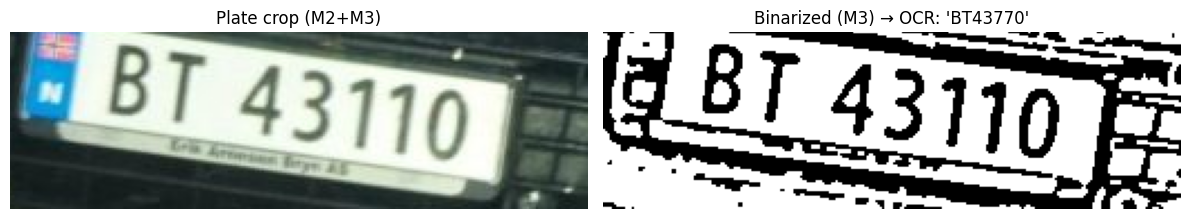

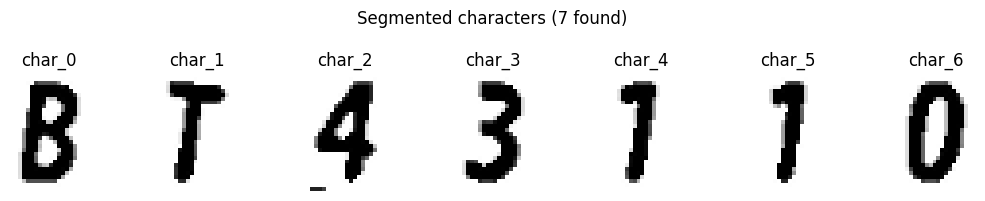

  OCR predicted: 'BT43770'
  ✓ Corrected to: 'BT43110'

[2/3] 2.jpg
------------------------------------------------------------
───────────────────────────────────────────────────────
  PIPELINE START
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M1  Grayscale + CLAHE + Bilateral + Auto-Canny
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M2  Morph Closing + Multi-pass Contour Filter
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M3  Perspective Warp + Adaptive Binarization
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M4  Character segmentation
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M5  OCR + Database + Accuracy
─────────────────────────────────

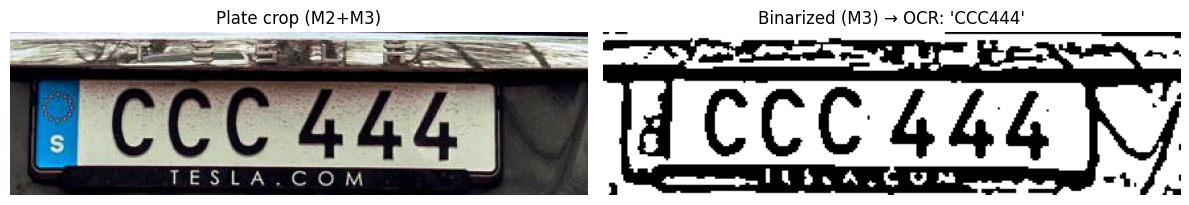

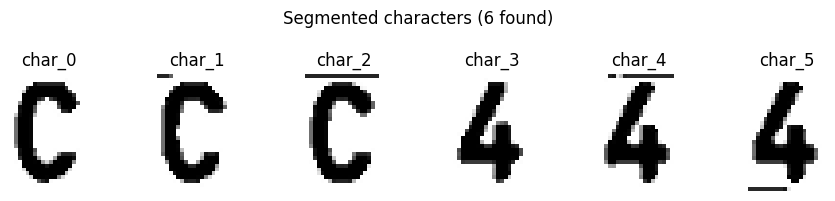

  OCR predicted: 'CCC444'
  ✓ Accepted: 'CCC444'

[3/3] 3.jpg
------------------------------------------------------------
───────────────────────────────────────────────────────
  PIPELINE START
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M1  Grayscale + CLAHE + Bilateral + Auto-Canny
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M2  Morph Closing + Multi-pass Contour Filter
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M3  Perspective Warp + Adaptive Binarization
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M4  Character segmentation
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M5  OCR + Database + Accuracy
───────────────────────────────────────

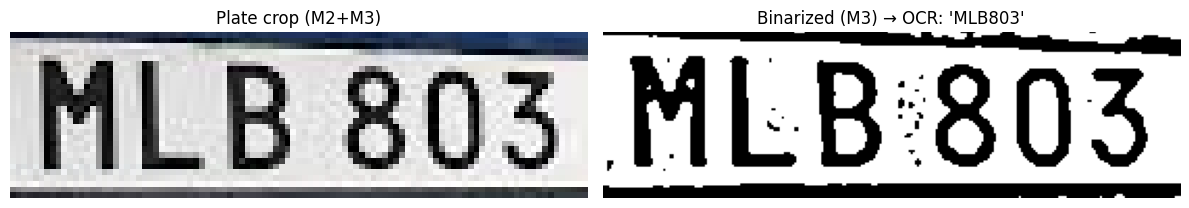

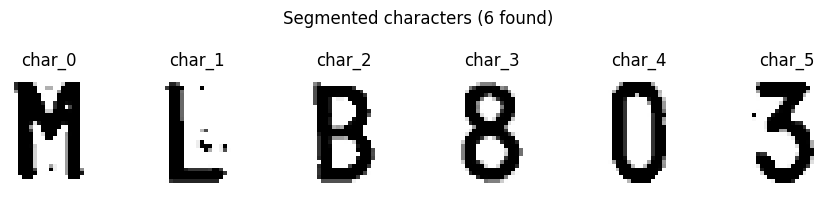

  OCR predicted: 'MLB803'
  ✓ Accepted: 'MLB803'

Writing 3 entries to ground_truth_demo.csv...
✅ Ground truth saved to ground_truth_demo.csv
   Total entries: 3
   Non-empty plates: 3


[{'image_id': '1.jpg', 'plate_text': 'BT43110', 'localization_correct': 1},
 {'image_id': '2.jpg', 'plate_text': 'CCC444', 'localization_correct': 1},
 {'image_id': '3.jpg', 'plate_text': 'MLB803', 'localization_correct': 1}]

In [17]:
# ══════════════════════════════════════════════════════════════
# CREATE A DEMO WITH ONLY 3 IMAGES
# ══════════════════════════════════════════════════════════════

# Take only first 3 images from your dataset
DEMO_IMAGES = DATASET_IMAGES[:3]

print("📸 DEMO IMAGES (3 samples):")
for i, img in enumerate(DEMO_IMAGES, 1):
    print(f"  {i}. {os.path.basename(img)}")

# Run manual labeling on ONLY these 3 images
build_ground_truth_interactive(DEMO_IMAGES, "ground_truth_demo.csv", auto_accept=False)

In [26]:
# ── Load ground truth CSV ───────────────────────────────────────────────────
import csv, os

def load_ground_truth(csv_path):
    """Load ground_truth.csv → dict keyed by image_id"""
    truth = {}
    if not csv_path or not os.path.isfile(csv_path):
        return truth
    with open(csv_path, newline='', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            key = row['image_id'].strip()
            plate = row.get('plate_text', '').strip()
            try:
                loc_ok = int(row.get('localization_correct', 1))
            except ValueError:
                loc_ok = 1
            truth[key] = {'plate': plate, 'loc_ok': loc_ok}
    return truth

# Look for ground_truth.csv
# GT_CSV = "ground_truth.csv" if os.path.isfile("ground_truth.csv") else None
GT_CSV = "ground_truth_demo.csv" if os.path.isfile("ground_truth_demo.csv") else None

GROUND_TRUTH = load_ground_truth(GT_CSV)

if GROUND_TRUTH:
    print(f"✅ Loaded ground truth for {len(GROUND_TRUTH)} image(s)")
    for k, v in list(GROUND_TRUTH.items())[:]:
        print(f"   {k}: '{v['plate']}' (loc_ok={v['loc_ok']})")
    # if len(GROUND_TRUTH) > 5:
    #     print(f"   ... and {len(GROUND_TRUTH) - 5} more")
else:
    print("⚠️  No ground_truth.csv found!")
    print("   Run the cell above to build it first.")


✅ Loaded ground truth for 3 image(s)
   1.jpg: 'BT43110' (loc_ok=1)
   2.jpg: 'CCC444' (loc_ok=1)
   3.jpg: 'MLB803' (loc_ok=1)


[batch] cleared previous rows in plates.db
[batch] running pipeline on 3 image(s)...

  [  1/3]  1.jpg
───────────────────────────────────────────────────────
  PIPELINE START
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M1  Grayscale + CLAHE + Bilateral + Auto-Canny
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M2  Morph Closing + Multi-pass Contour Filter
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M3  Perspective Warp + Adaptive Binarization
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M4  Character segmentation
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
  M5  OCR + Database + Accuracy
───────────────────────────────────────────────────────

PI

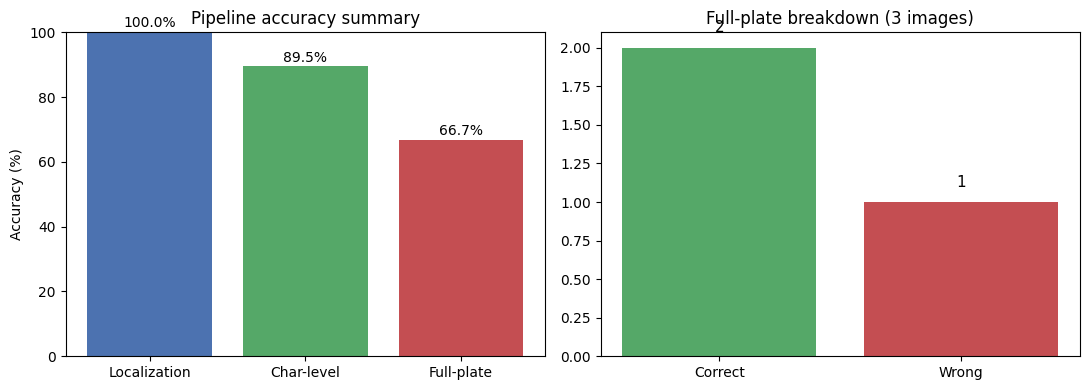

In [28]:
# ── Run the full pipeline on every dataset image ────────────────────────────
# Reuses the existing run_pipeline() so nothing else changes.
# All results are stored in plates.db, then m5_accuracy_report() is called.

def run_batch_on_dataset(images=None, ground_truth=None,
                        clear_db_first=True, visualize_each=False):
    """
    Args:
        images          : list of image paths (defaults to DATASET_IMAGES)
        ground_truth    : dict from load_ground_truth() (defaults to GROUND_TRUTH)
        clear_db_first  : wipe plates.db before running so we get a clean batch
        visualize_each  : if True, show every M1..M5 plot per image (slow)
    """
    images       = images       if images is not None       else DATASET_IMAGES
    ground_truth = ground_truth if ground_truth is not None else GROUND_TRUTH

    if clear_db_first:
        db_clear()
        print("[batch] cleared previous rows in plates.db")

    total = len(images)
    if total == 0:
        print("[batch] no images to process")
        return None

    print(f"[batch] running pipeline on {total} image(s)...\n")

    successes, failures = 0, 0
    for i, img_path in enumerate(images, 1):
        img_name = os.path.basename(img_path)
        gt       = ground_truth.get(img_name)
        gt_plate = gt['plate']  if gt else None
        gt_loc   = gt['loc_ok'] if gt else None

        print(f"  [{i:3d}/{total}]  {img_name}")
        try:
            run_pipeline(
                img_path,
                ground_truth=gt_plate,
                localization_correct=gt_loc,
                visualize=visualize_each,
            )
            successes += 1
        except Exception as e:
            failures += 1
            print(f"      ✗ pipeline error: {type(e).__name__}: {e}")
            # still log the failure so the DB has one row per image attempted
            try:
                db_insert(
                    image_path=img_name,
                    predicted_plate="",
                    ground_truth=gt_plate,
                    localization_correct=gt_loc,
                    recognition_correct=False if gt_plate else None,
                    char_accuracy=0.0 if gt_plate else None,
                    avg_confidence=0.0,
                )
            except Exception:
                pass

    print(f"\n[batch] done: {successes} ok, {failures} failed")
    print("[batch] generating final accuracy report...\n")
    return m5_accuracy_report()


# Kick off the batch run
batch_results =  run_batch_on_dataset(images=DEMO_IMAGES, ground_truth=GROUND_TRUTH, clear_db_first=True, visualize_each=False)


In [29]:
# ── Inspect plates.db (full contents) ───────────────────────────────────────
import sqlite3, pandas as pd

with sqlite3.connect(DB_PATH) as _conn:
    _df = pd.read_sql_query("SELECT * FROM plates ORDER BY id", _conn)

print(f"plates.db now contains {len(_df)} row(s)\n")
_df


plates.db now contains 3 row(s)



,id,image_path,predicted_plate,ground_truth,localization_correct,recognition_correct,char_accuracy,avg_confidence,timestamp
0,1036,1.jpg,BT43770,BT43110,1,0,0.714286,73.14,2026-05-10T02:09:49
1,1037,2.jpg,CCC444,CCC444,1,1,1.000000,88.50,2026-05-10T02:09:50
2,1038,3.jpg,MLB803,MLB803,1,1,1.000000,63.17,2026-05-10T02:09:52


## 🌐 React Frontend Server
> Run this cell once after running M1/M2/M3 cells. Then open the React app. Keep this cell running.

In [21]:
# # 🌐 React Frontend Server (CORRECTED)
# import subprocess, sys, threading, base64, tempfile, os, io
# import cv2, numpy as np
# from flask import Flask, request, jsonify
# from flask_cors import CORS

# # Install deps silently
# for pkg in ['flask', 'flask-cors']:
#     subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], capture_output=True)

# app = Flask(__name__)
# CORS(app)

# def to_b64(img):
#     """Convert image to base64 string (handles grayscale and color)"""
#     if img is None: 
#         return None
#     if len(img.shape) == 2:
#         img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    
#     elif len(img.shape) == 3 and img.shape[2] == 4:
#         img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
    
#     # Now encode as PNG
#     _, buf = cv2.imencode('.png', img)
#     return base64.b64encode(buf).decode()

# @app.route('/health')
# def health():
#     return jsonify({'ok': True})

# @app.route('/run', methods=['POST'])
# def run():
#     try:
#         # Read and decode image
#         raw = np.frombuffer(request.files['image'].read(), np.uint8)
#         img = cv2.imdecode(raw, cv2.IMREAD_COLOR)
#         if img is None:
#             return jsonify({'ok': False, 'error': 'Cannot decode image'}), 400

#         # Save to temp file
#         with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as t:
#             cv2.imwrite(t.name, img)
#             path = t.name

#         try:
#             # IMPORTANT: DON'T DELETE YET - we need this file for M1, M2, M3
#             # Run the complete pipeline (returns M1-M5 data)
#             binary, all_meta, character_images, char_paths, plate_text = run_pipeline(
#                 path, visualize=False
#             )
            
#             # Extract data from all_meta
#             m1 = all_meta.get('M1', {})
#             m2 = all_meta.get('M2', {})
#             m3 = all_meta.get('M3', {})
#             m4 = all_meta.get('M4', {})
#             m5 = all_meta.get('M5', {})
            
#             # Re-run M1, M2, M3 to get the images for frontend
#             # BUT use the SAME file path (it still exists)
#             m1_original, m1_gray, m1_edges, m1_meta = m1_edge_detection(path, visualize=False)
            
#             # M2 needs original image and edges
#             original = cv2.imread(path)  # Re-read original
#             plate_crop, contour, best_rect, m2_meta = m2_plate_candidate(original, m1_edges, visualize=False)
            
#             # M3 needs original and best_rect
#             binary_img, warped_img, m3_meta = m3_perspective_binarize(original, best_rect, visualize=False)
            
#             # Create detection overlay for M2
#             debug = original.copy()
#             rx, ry, rw, rh = best_rect
#             cv2.rectangle(debug, (rx, ry), (rx+rw, ry+rh), (99, 102, 241), 3)
#             cv2.putText(debug, f"{m2_meta.get('source', '?')} {m2_meta.get('score', 0):.3f}",
#                         (rx, max(ry-8, 18)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (99, 102, 241), 2)

#             # Prepare character images for frontend
#             char_list_b64 = []
#             for char_img in character_images:
#                 char_list_b64.append(to_b64(char_img))

#             # Build warnings list
#             m1_quality = np.mean(m1_edges) / 255.0 if m1_edges is not None else 0
#             m2_score = float(m2_meta.get('score', 0))
#             m3_score = float(m3_meta.get('warp_score', 0))
            
#             warns = []
#             if m1_quality < 0.01:
#                 warns.append('M1: Very low edge signal')
#             if m2_score < 0.002:
#                 warns.append('M2: Weak plate confidence')
#             if m3_score < 0.2:
#                 warns.append('M3: Low warp score')

#             oh, ow = original.shape[:2]
            
#             response = {
#                 'ok': True,
#                 'confidence': round((m2_score + m3_score) / 2, 4) if m2_score + m3_score > 0 else 0.5,
#                 'warnings': warns,
#                 'size': [ow, oh],
#                 'plate_text': plate_text,
#                 'm1': {
#                     'meta': {
#                         'clip': m1_meta.get('clip', 'N/A'),
#                         'canny': str(m1_meta.get('canny', 'N/A')),
#                         'contrast': m1_meta.get('contrast', 'N/A'),
#                         'texture': m1_meta.get('texture', 'N/A')
#                     },
#                     'original': to_b64(original),
#                     'gray': to_b64(m1_gray),
#                     'edges': to_b64(m1_edges),
#                 },
#                 'm2': {
#                     'meta': {
#                         'score': round(m2_meta.get('score', 0), 4),
#                         'source': m2_meta.get('source', 'N/A'),
#                         'rect': str(best_rect)
#                     },
#                     'detection': to_b64(debug),
#                     'crop': to_b64(plate_crop),
#                 },
#                 'm3': {
#                     'meta': {
#                         'warp_mode': m3_meta.get('warp_mode', 'N/A'),
#                         'warp_score': round(m3_meta.get('warp_score', 0), 4),
#                         'binarization': m3_meta.get('binarization', 'Otsu/Adaptive'),
#                         'out_size': str(m3_meta.get('out_size', 'N/A'))
#                     },
#                     'warped': to_b64(warped_img),
#                     'binary': to_b64(binary_img),
#                 },
#                 'm4': {
#                     'meta': {
#                         'num_characters': m4.get('num_characters', 0),
#                         'method': m4.get('method', 'N/A'),
#                         'target_size': m4.get('target_size', '20×30')
#                     },
#                     'characters': char_list_b64,
#                     'num_characters': len(character_images)
#                 }
#             }
            
#             return jsonify(response)
            
#         finally:
#             # DELETE FILE ONLY AFTER WE'RE DONE WITH IT
#             try:
#                 os.unlink(path)
#             except:
#                 pass  # File might already be deleted
        
#     except Exception as e:
#         import traceback
#         print(f"Error: {e}")
#         print(traceback.format_exc())
#         return jsonify({
#             'ok': False, 
#             'error': str(e), 
#             'trace': traceback.format_exc()
#         }), 500

# @app.route('/')
# def index():
#     return '''<body style="font-family:monospace;background:#07080d;color:#f0f2ff;padding:40px">
#     <h2>✅ LPR Flask API is running</h2>
#     <p style="color:#6b7094;margin-top:12px">This is the backend API. Open your React app at:</p>
#     <a href="http://localhost:3000" style="color:#818cf8;font-size:20px">http://localhost:3000</a>
#     <p style="color:#6b7094;margin-top:24px">Available endpoints: GET /health &nbsp;|&nbsp; POST /run</p>
#     </body>'''

# def _run():
#     print('\n  ✅ Flask API → http://localhost:5050')
#     print('  🌐 React app → http://localhost:3000  ← open THIS in your browser\n')
#     app.run(port=5050, debug=False, use_reloader=False)

# # Check if server is already running
# import socket
# def is_port_open(port):
#     sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
#     try:
#         sock.connect(('localhost', port))
#         sock.close()
#         return True
#     except:
#         return False

# if not is_port_open(5050):
#     t = threading.Thread(target=_run, daemon=True)
#     t.start()
#     import time
#     time.sleep(1)
#     print('✅  Server ready.')
# else:
#     print('⚠️  Server already running on port 5050')